In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import IsolationForest
from scipy.linalg import lstsq
from sklearn.model_selection import train_test_split
import cvxpy as cp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


In [12]:
df_data = pd.read_parquet("training_data/initial_dataset.parquet")
df_train_detached = pd.read_parquet(
    "training_data/data_detached_with_weather.parquet")
type(df_data)
type(df_train_detached)
df_train_detached

unique_ids = df_train_detached["Property_ID"].unique()
id_use = unique_ids[0]
df_house = pd.read_csv('training_data/home_characteristics.csv')

# List of columns to check for missingness
cols = [
    "Bedrooms", "Floor_Height", "Habitable_Rooms", "House_Age",
    "House_Form", "No_Storeys", "No_Underfloor",
    "Total_Floor_Area", "Wall_Type", "MCS_DHWAnnual","HP_Size_kW"
]

# calculate min capacity in home 
cp_air = 1.005  #kJ/kgK
rho_air = 1.225  # kg/m^3
kj_to_kWh = 1/3600
df_house["Volume"] = df_house["Total_Floor_Area"] * df_house["Floor_Height"]
df_house["Min Capacity"] = df_house["Volume"] * cp_air * rho_air * kj_to_kWh

df_home_values = df_house[df_house["Property_ID"].isin(unique_ids)]

summary = df_home_values[["Property_ID", "Min Capacity"]].drop_duplicates()
print(summary)

home_dict = df_home_values.set_index("Property_ID").to_dict(orient="index")

     Property_ID  Min Capacity
76       EOH3196      0.086941
318      EOH0413      0.094570
585      EOH2329      0.099645
736      EOH1637      0.088733
1149     EOH3154      0.116411
1156     EOH2675      0.124696
1569     EOH1485      0.115696
1692     EOH0546      0.088239
2066     EOH0279      0.138493
2381     EOH1703      0.074688


In [13]:
df_single = df_train_detached[
df_train_detached["Property_ID"] == id_use].copy()

#re-adjust Heat Pump Diff and add temp differences
df_single["Heat_Pump_Energy_Output_Diff"] = df_single[
    "Heat_Pump_Energy_Output"].diff()
df_single["Internal_Temperature_Diff"] = df_single[
    "Internal_Air_Temperature"].diff()
df_single["Internal_Ambient_Temperature_Diff"] = \
    (df_single["External_Air_Temperature"] -
     df_single["Internal_Air_Temperature"])

# 1. Drop columns with almost all missing data (e.g., more than 90% missing)
threshold = 0.90 * len(df_single)
df_single_cleaned = df_single.dropna(axis=1, thresh=threshold)
#print("Columns dropped due to high missing values:")
#print(df_single.columns.difference(df_single_cleaned.columns).tolist())

df_single = df_single_cleaned

#print("\nColumns remaining after dropping highly missing columns:")
#print(df_single.columns.tolist())

df_single = df_single.set_index('Timestamp')
df_single = df_single.sort_index()

# Apply interpolation with a limit of 4 (for 2 hours of half-hourly data)
numeric_cols = df_single.select_dtypes(include=['number']).columns
df_single_numeric_interpolated = df_single[numeric_cols].interpolate(
    method='time', limit=4, limit_direction='both')

df_single_interpolated = df_single.copy()
df_single_interpolated[numeric_cols] = df_single_numeric_interpolated

# After interpolation, drop rows that still contain NaN values (meaning they were missing for > 2 hours)
initial_rows = len(df_single_interpolated)
df_single_processed = df_single_interpolated.dropna()

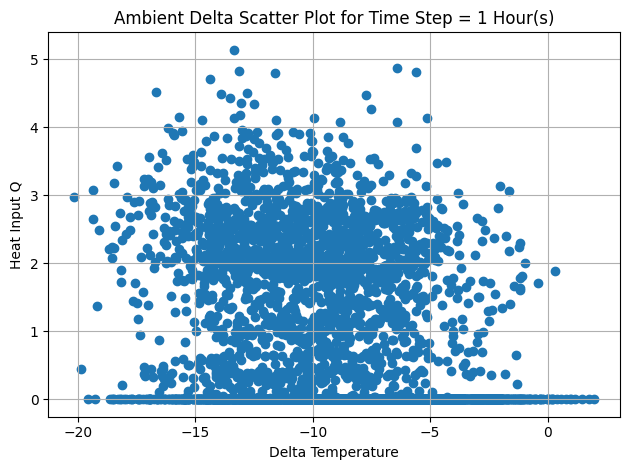

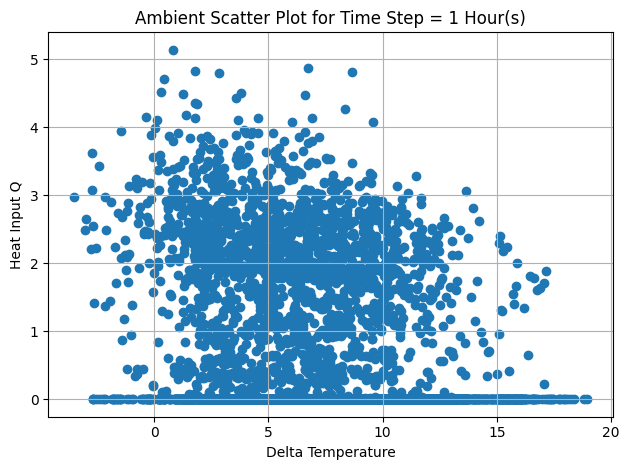

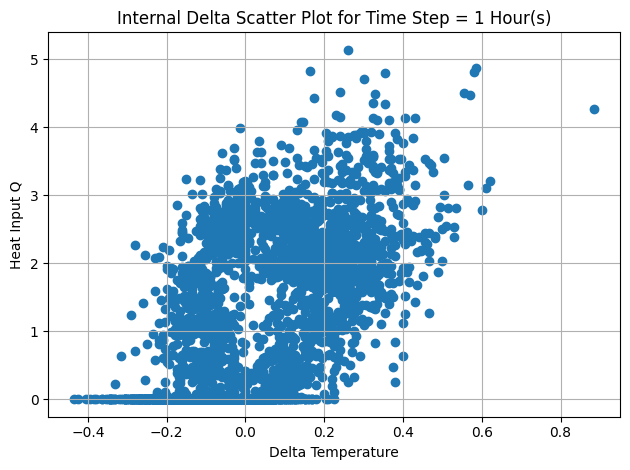

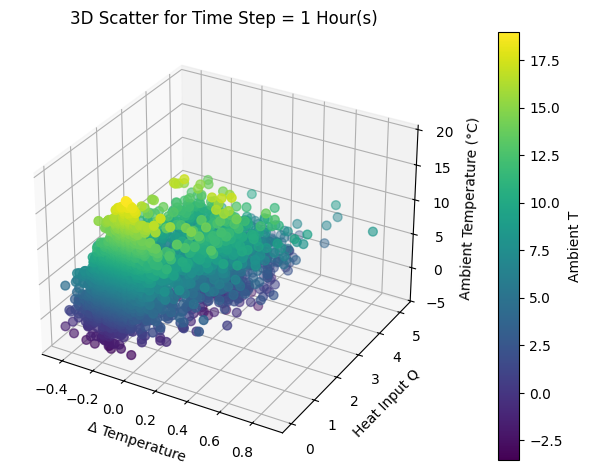

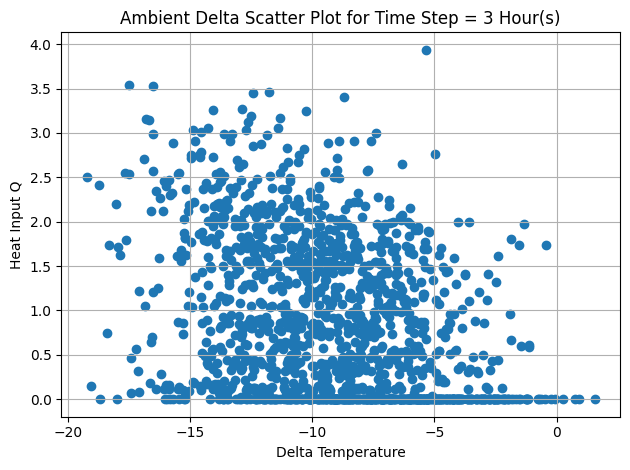

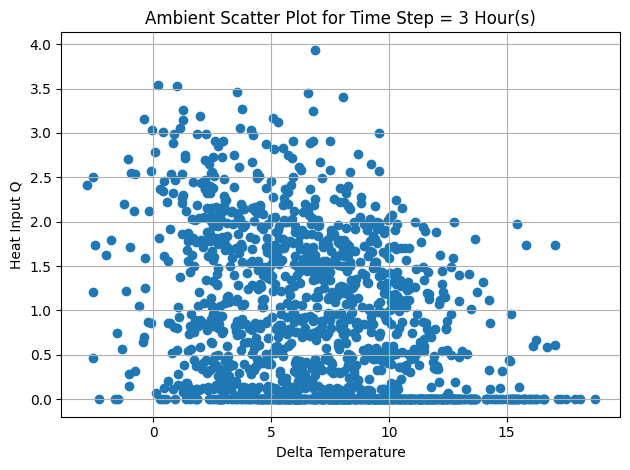

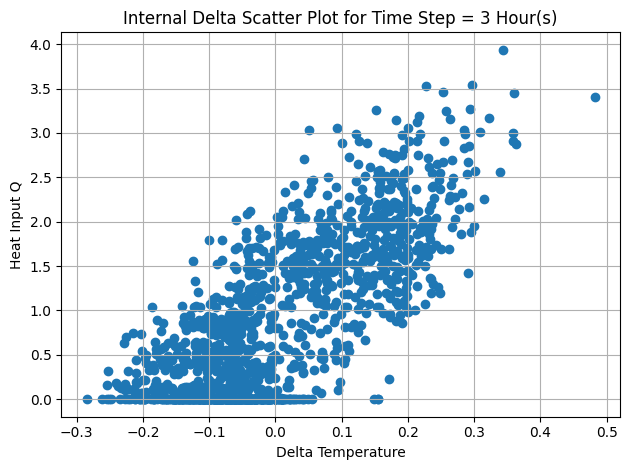

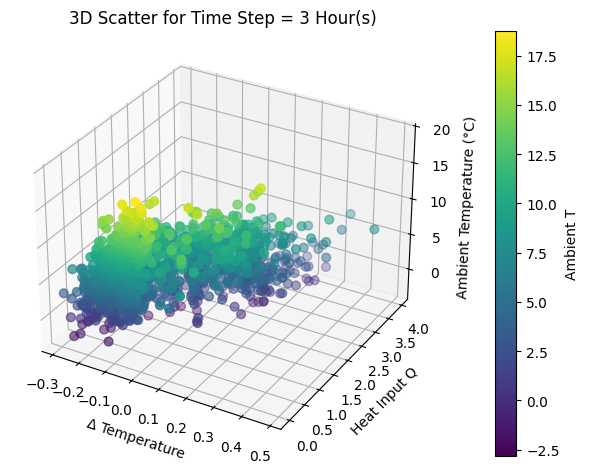

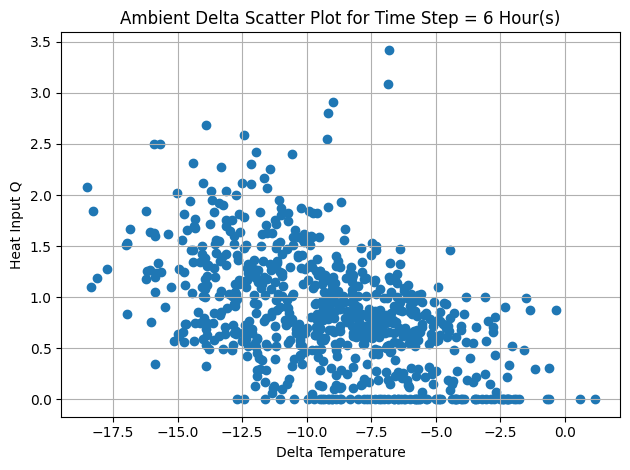

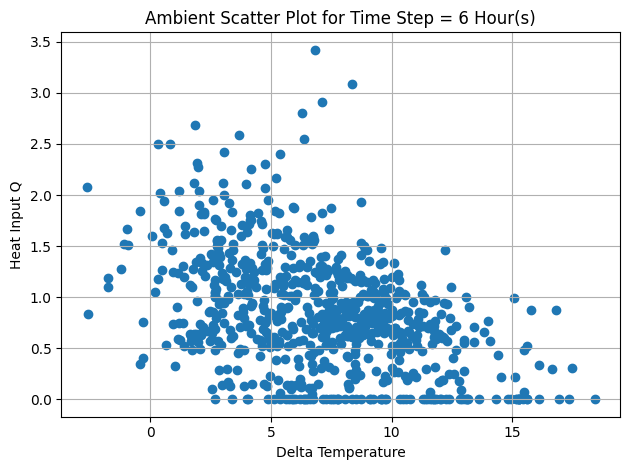

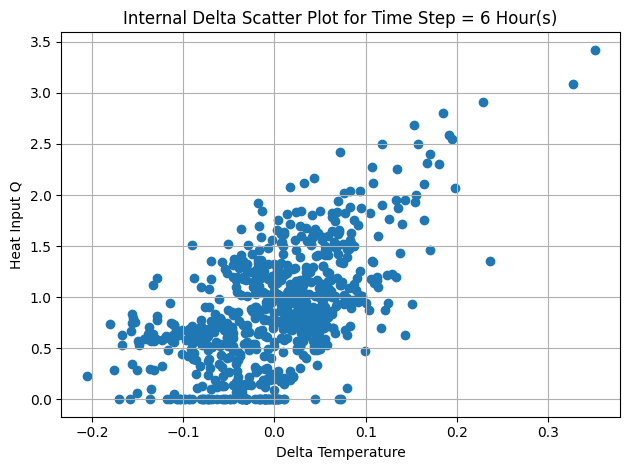

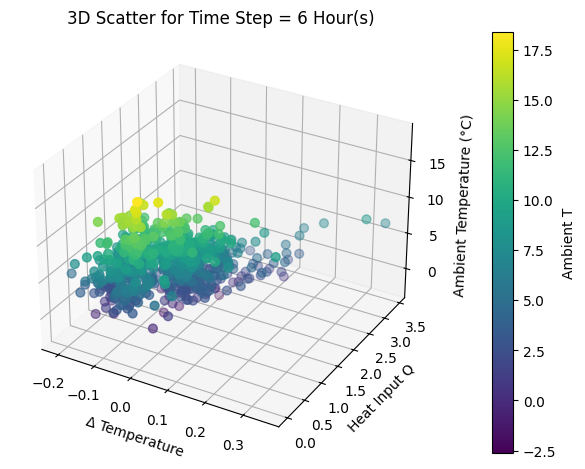

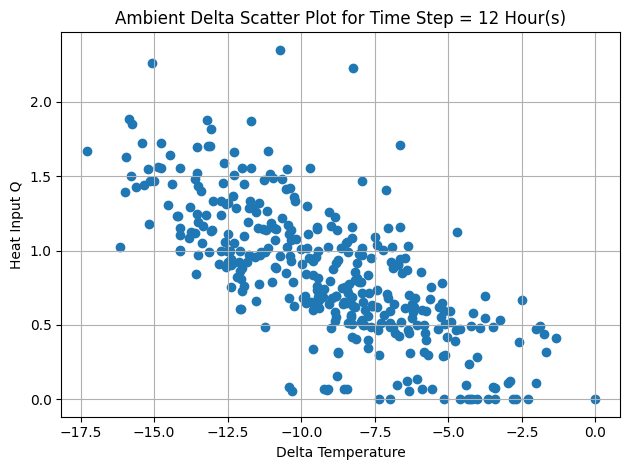

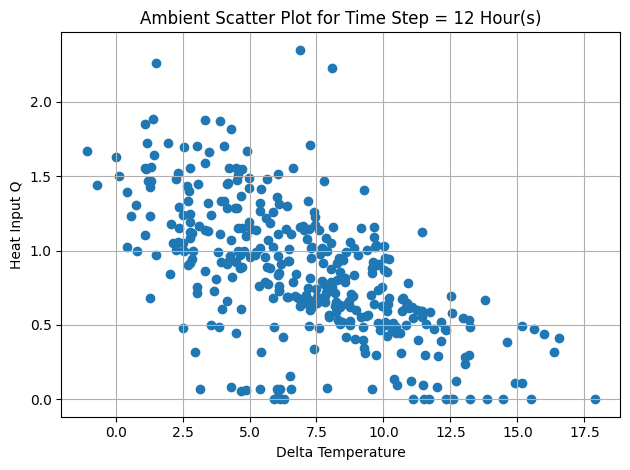

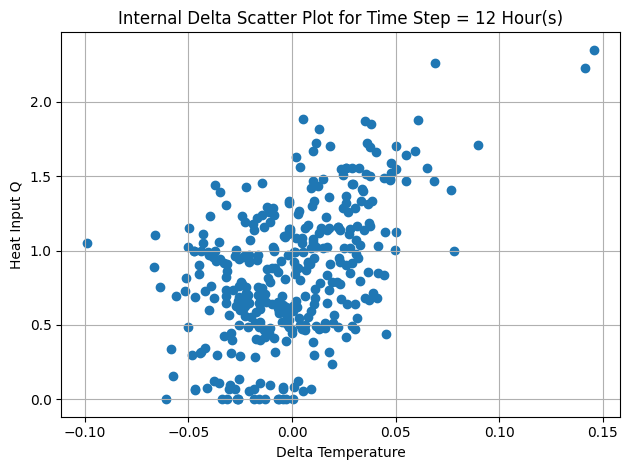

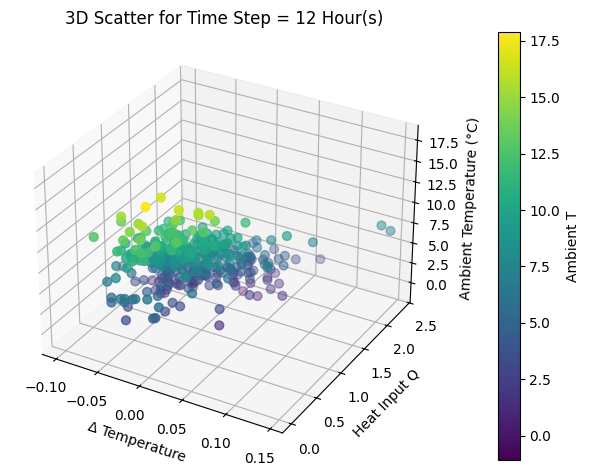

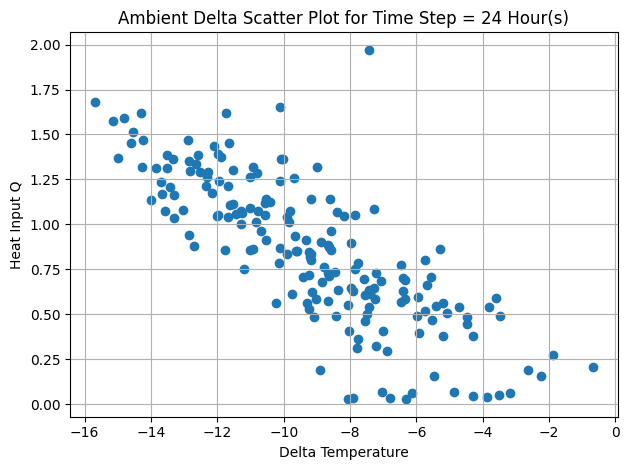

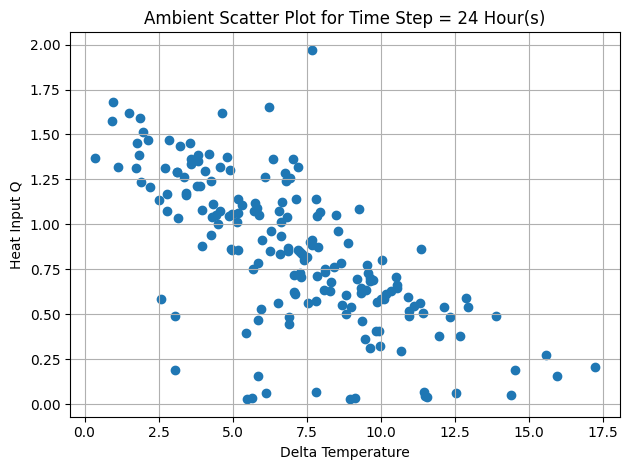

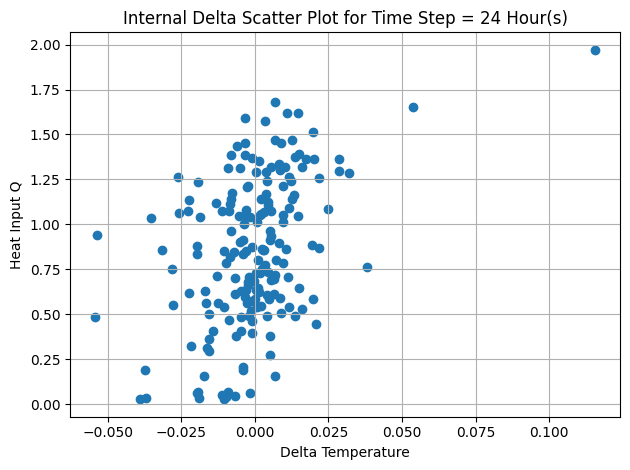

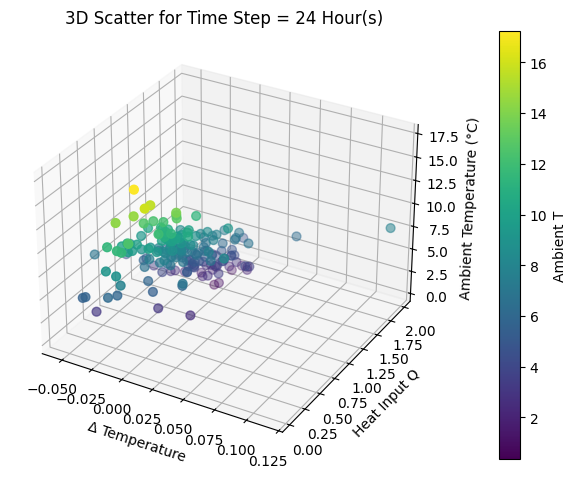

In [14]:
df_heating_single = df_single_processed.copy()

# Time range
t_start = pd.to_datetime("2021-10-01 00:00:00")
t_end = pd.to_datetime("2022-3-31 23:59:00")
df_heating_only = df_heating_single[
    (df_heating_single.index >= t_start) & (df_heating_single.index <= t_end)
].copy()

df_heating_only.drop("Property_ID", axis=1, inplace=True)
df_heating_only.drop("half-hour", axis=1, inplace=True)
df_heating_only.drop("Date", axis=1, inplace=True)
df_heating_only.drop("has_data", axis=1, inplace=True)


t_step_try = [1, 3, 6, 12, 24]

for i in t_step_try:
    df_numeric = df_heating_only.select_dtypes(include='number')

    # Resample and compute mean
    df_resampled = df_numeric.resample(f'{i}h').mean()

    # Extract variables
    delta_T_a_heat = df_resampled["Internal_Ambient_Temperature_Diff"]
    q_heat_only = df_resampled["Heat_Pump_Energy_Output_Diff"]
    delta_T_i_heat = df_resampled["Internal_Temperature_Diff"]
    T_ambient = df_resampled["External_Air_Temperature"]
    # Create new scatter plot
    plt.figure()
    plt.scatter(delta_T_a_heat, q_heat_only)
    plt.title(f"Ambient Delta Scatter Plot for Time Step = {i} Hour(s)")
    plt.xlabel("Delta Temperature")
    plt.ylabel("Heat Input Q")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    plt.figure()
    plt.scatter(T_ambient, q_heat_only)
    plt.title(f"Ambient Scatter Plot for Time Step = {i} Hour(s)")
    plt.xlabel("Delta Temperature")
    plt.ylabel("Heat Input Q")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    plt.figure()
    plt.scatter(delta_T_i_heat, q_heat_only)
    plt.title(f"Internal Delta Scatter Plot for Time Step = {i} Hour(s)")
    plt.xlabel("Delta Temperature")
    plt.ylabel("Heat Input Q")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    fig = plt.figure()
    ax  = fig.add_subplot(111, projection='3d')
    p   = ax.scatter(
        delta_T_i_heat,
        q_heat_only,
        T_ambient,           # third axis
        c=T_ambient,
        cmap='viridis',
        depthshade=True,
        s=40
    )
    ax.set_xlabel("Δ Temperature")
    ax.set_ylabel("Heat Input Q")
    ax.set_zlabel("Ambient Temperature (°C)")
    fig.colorbar(p, ax=ax, pad=0.1, label='Ambient T')
    plt.title(f"3D Scatter for Time Step = {i} Hour(s)")
    plt.tight_layout()
    plt.show()
    


Total windows:    4368
Anomalies found:  437


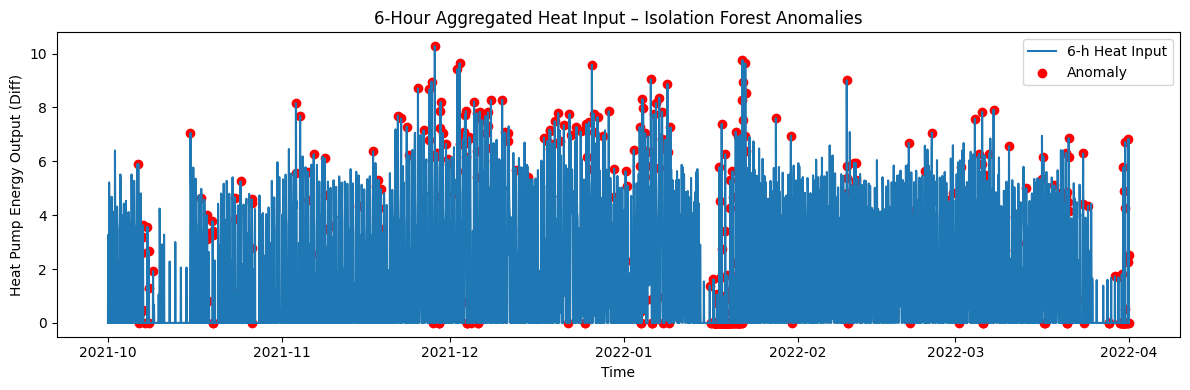

In [15]:
# 1. Subset to your desired time range
t_start = pd.to_datetime("2021-10-01 00:00:00")
t_end   = pd.to_datetime("2022-03-31 23:59:00")
df = df_heating_single.loc[t_start:t_end].copy()

# 2. Add the sinusoidal time‐of‐day features
df['sin_h'] = np.sin(2 * np.pi * df.index.hour / 24)
df['cos_h'] = np.cos(2 * np.pi * df.index.hour / 24)

# 3. Resample to windows
agg_dict = {
    'Heat_Pump_Energy_Output_Diff': 'sum',   # total heat input
    'Internal_Ambient_Temperature_Diff': 'mean',
    #'External_Air_Temperature': 'mean',
    'Internal_Temperature_Diff': 'mean',
    'Internal_Air_Temperature': 'mean',
    #'sin_h': 'mean',
    #'cos_h': 'mean'
}
df6h = df.resample('1h').agg(agg_dict).dropna()

# 4. Prepare your feature matrix
features = [
    'Heat_Pump_Energy_Output_Diff',
    'Internal_Ambient_Temperature_Diff',
    #'External_Air_Temperature',
    'Internal_Temperature_Diff',
    'Internal_Air_Temperature',
    #'sin_h',
    #'cos_h'
]
X = df6h[features]

# 5. Fit the Isolation Forest (no `behaviour` parameter)
iso = IsolationForest(
    n_estimators=100,
    contamination=0.10,    # expecting ~x% anomalies
    random_state=42
)
iso.fit(X)

# 6. Score and flag anomalies
df6h['anomaly_score'] = iso.decision_function(X)   # higher → more normal
df6h['is_anomaly']    = iso.predict(X) == -1       # -1 = anomaly

# 7. Quick summary
print(f"Total windows:    {len(df6h)}")
print(f"Anomalies found:  {df6h['is_anomaly'].sum()}")

# 8. Plot the 6-h heat input with anomalies highlighted
plt.figure(figsize=(12, 4))
plt.plot(df6h.index, df6h['Heat_Pump_Energy_Output_Diff'], label='6-h Heat Input')
plt.scatter(
    df6h.index[df6h['is_anomaly']],
    df6h.loc[df6h['is_anomaly'], 'Heat_Pump_Energy_Output_Diff'],
    color='red',
    label='Anomaly'
)
plt.title("6-Hour Aggregated Heat Input – Isolation Forest Anomalies")
plt.xlabel("Time")
plt.ylabel("Heat Pump Energy Output (Diff)")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# 9. Identify which calendar days have ≥1 anomaly
df6h['date'] = df6h.index.date
anomaly_days = np.unique(df6h.loc[df6h['is_anomaly'], 'date'])
print(f"\nNumber of days with at least one anomaly: {len(anomaly_days)}")

# 10. Compute daily metrics (from the 6-h windows)
daily_metrics = (
    df6h
    .groupby('date')
    .agg(daily_heat_input=('Heat_Pump_Energy_Output_Diff', 'sum'),
         mean_external_temp=('External_Air_Temperature', 'mean'),
         mean_internal_temp=('Internal_Air_Temperature', 'mean'))
)

# 11. Filter to only those anomaly days
daily_anomaly = daily_metrics.loc[anomaly_days]

print("\nExample anomaly days and their daily metrics:")
print(daily_anomaly.sample(5))  # 5 random days

# Optional: choose how many anomaly days to visualize
max_plots = 5  # Change as needed
plot_days = anomaly_days[:max_plots]  # first N anomaly days

for day in plot_days:
    # 1. Filter original 30-min data for this day
    mask = df_heating_single.index.date == day
    df_day = df_heating_single.loc[mask].copy()

    # 2. Add anomaly flag from df6h: mark points that were anomalies in the 6h data
    # For highlighting, use df6h index nearest to df_day intervals if needed
    anomaly_times = df6h.loc[(df6h['is_anomaly']) & (df6h['date'] == day)].index
    df_day['is_anomaly'] = df_day.index.floor('6H').isin(
        anomaly_times)  # map to nearest 6H

    # 3. Plot everything
    fig, ax1 = plt.subplots(figsize=(14, 5))

    # Heat input on primary y-axis
    l1 = ax1.plot(
        df_day.index,
        df_day['Heat_Pump_Energy_Output_Diff'],
        label='Heat Input (30 min)',
        color='blue'
    )
    # Highlight anomalies in red dots
    ax1.scatter(
        df_day.loc[df_day['is_anomaly']].index,
        df_day.loc[df_day['is_anomaly'], 'Heat_Pump_Energy_Output_Diff'],
        color='red', s=80, label='Anomaly'
    )

    ax1.set_xlabel('Time')
    ax1.set_ylabel('Heat Input (kWh)')
    ax1.tick_params(axis='y')

    # Temperature on secondary y-axis
    ax2 = ax1.twinx()
    l2 = ax2.plot(
        df_day.index,
        df_day['External_Air_Temperature'],
        linestyle='--',
        color='orange',
        label='Outdoor Temp'
    )
    l3 = ax2.plot(
        df_day.index,
        df_day['Internal_Air_Temperature'],
        linestyle=':',
        color='green',
        label='Indoor Temp'
    )
    ax2.set_ylabel('Temperature (°C)')
    ax2.tick_params(axis='y')

    # Combine legends
    lines = l1 + l2 + l3
    labels = [l.get_label() for l in lines] + ['Anomaly']
    ax1.legend(lines + [
        plt.Line2D([0], [0], marker='o', color='red', linestyle='None')],
               labels, loc='upper left')

    plt.title(f'30-Minute Heat Input & Temps on {day} (Anomalies Highlighted)')
    plt.tight_layout()
    plt.show()


Number of days with at least one anomaly: 104


KeyError: "Column(s) ['External_Air_Temperature'] do not exist"

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# 9. Identify which calendar days have ≥1 anomaly
df6h['date'] = df6h.index.date
anomaly_days = np.unique(df6h.loc[df6h['is_anomaly'], 'date'])
print(f"\nNumber of days with at least one anomaly: {len(anomaly_days)}")

# 10. Compute daily metrics (from the 6-h windows)
daily_metrics = (
    df6h
    .groupby('date')
    .agg(daily_heat_input       = ('Heat_Pump_Energy_Output_Diff', 'sum'),
         mean_external_temp     = ('External_Air_Temperature',       'mean'),
         mean_internal_temp     = ('Internal_Air_Temperature',       'mean'))
)

# 11. Filter to only those anomaly days
daily_anomaly = daily_metrics.loc[anomaly_days]

# 12. Show a few example days
print("\nExample anomaly days and their daily metrics:")
print(daily_anomaly.sample(5))    # pick 5 random example dayse


Number of days with at least one anomaly: 133

Example anomaly days and their daily metrics:
            daily_heat_input  mean_external_temp  mean_internal_temp
date                                                                
2021-12-30            41.356           11.344375           16.646458
2021-10-04            19.701            9.846667           17.864583
2021-10-26            26.044           12.931042           16.756042
2021-10-08             7.547           15.946875           18.190000
2021-11-23            41.125            7.207083           15.767917


In [8]:
anomaly_days[3]

datetime.date(2021, 10, 4)

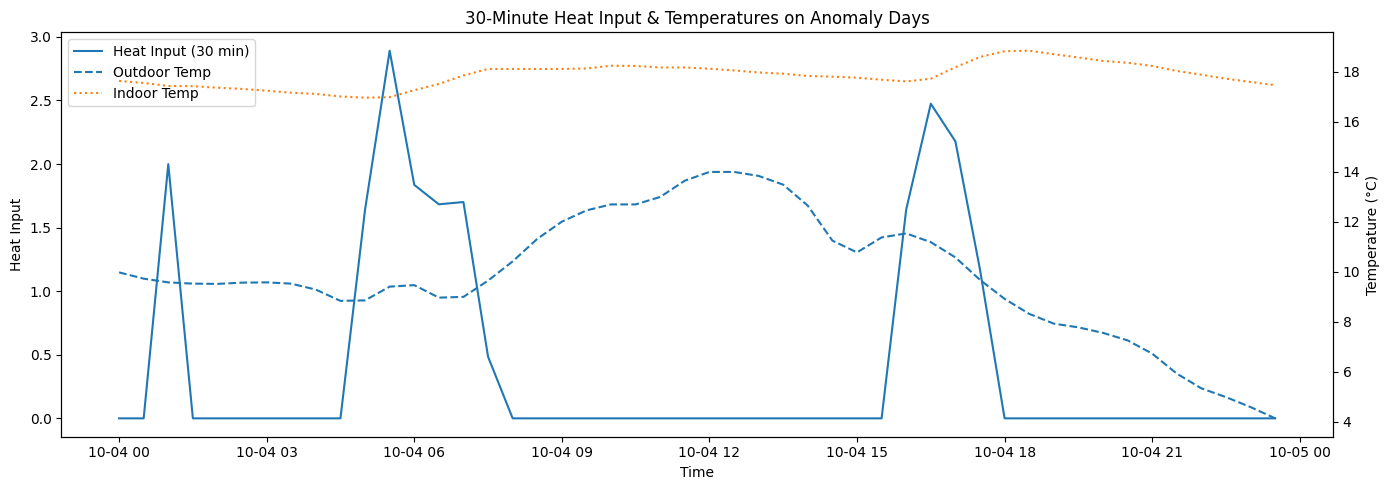

In [9]:

# 1. Re-filter your original 30-min data to the same date range
df30 = df_heating_single.loc[t_start:t_end].copy()

# 2. Keep only the anomaly days via np.isin
mask = np.isin(df30.index.date, anomaly_days[3])
df30 = df30[mask]

# 3. Plot everything
fig, ax1 = plt.subplots(figsize=(14, 5))

# Heat input on primary y-axis
l1, = ax1.plot(
    df30.index,
    df30['Heat_Pump_Energy_Output_Diff'],
    label='Heat Input (30 min)',
)
ax1.set_xlabel('Time')
ax1.set_ylabel('Heat Input')
ax1.tick_params(axis='y')

# Temperature on a secondary y-axis
ax2 = ax1.twinx()
l2, = ax2.plot(
    df30.index,
    df30['External_Air_Temperature'],
    linestyle='--',
    label='Outdoor Temp'
)
l3, = ax2.plot(
    df30.index,
    df30['Internal_Air_Temperature'],
    linestyle=':',
    label='Indoor Temp'
)
ax2.set_ylabel('Temperature (°C)')
ax2.tick_params(axis='y')

# Combine legends
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('30-Minute Heat Input & Temperatures on Anomaly Days')
plt.tight_layout()
plt.show()
